# Propensity Score

En este capítulo, daremos un giro fascinante a nuestra caja de herramientas de inferencia causal. Hasta ahora, nos hemos centrado en ajustar los confusores mediante la regresión lineal y la ortogonalización, técnicas que buscan modelar directamente el resultado $Y$. Ahora, exploraremos una perspectiva complementaria: el **Modelado del Mecanismo de Asignación**.

En lugar de centrarnos únicamente en cómo las variables afectan al resultado, aprenderemos a modelar la probabilidad de que una unidad reciba el tratamiento, concepto conocido como **Propensity Score** o Puntaje de Propensión:

$$
e(x) = P(T=1 | X=x)
$$

A lo largo de esta sección, cubriremos:

1.  **Ponderación por Propensity Score:** Aprenderemos a usar las predicciones del modelo para reequilibrar nuestros datos (reweighting), creando un "pseudo-población" donde el tratamiento es independiente de los confusores observados.
2.  **Robustez Doble (Double Robustness):** Descubriremos cómo combinar los modelos de regresión del Capítulo 4 con la ponderación por propensión. Esta técnica es sumamente poderosa porque nos brinda una "doble oportunidad" de obtener un estimador insesgado: basta con que uno de los dos modelos (el del resultado o el de la propensión) esté correctamente especificado.
3.  **Tratamientos Binarios y Continuos:** Aunque estas técnicas brillan en escenarios de tratamientos discretos, exploraremos extensiones para aplicarlas cuando el tratamiento es una variable continua.


In [1]:
import polars as pl
import numpy as np

In [2]:
df = pl.read_csv("../data/management_training.csv")
df

departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size
i64,i64,f64,i64,i64,i64,i64,f64,f64,i64
76,1,0.277359,6,4,2,4,0.614261,0.224077,843
76,1,-0.449646,4,8,2,4,0.069636,0.224077,843
76,1,0.769703,6,4,2,4,0.866918,0.224077,843
76,1,-0.121763,6,4,2,4,0.029071,0.224077,843
76,1,1.526147,6,4,1,4,0.589857,0.224077,843
…,…,…,…,…,…,…,…,…,…
1,0,0.808867,7,4,2,3,-2.078306,1.005063,323
1,0,-0.156063,7,4,2,3,-0.889201,1.005063,323
1,0,0.37082,2,8,1,3,-1.490572,1.005063,323


## Adjusting with Regression

In [3]:
import statsmodels.formula.api as smf

smf.ols("engagement_score ~ intervention",
    data=df).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-0.2347,0.014,-16.619,0.000,-0.262,-0.207
intervention,0.4346,0.019,22.616,0.000,0.397,0.472


In [4]:
model = smf.ols("""engagement_score ~ intervention 
        + tenure + last_engagement_score + department_score
        + n_of_reports + C(gender) + C(role)""", data=df.to_pandas()).fit()
print("ATE:", model.params["intervention"])
print("95% CI:", model.conf_int().loc["intervention", :].values.T)

ATE: 0.26779085766768534
95% CI: [0.23357751 0.30200421]


In [5]:
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,-1.7206,0.052,-32.942,0.000,-1.823,-1.618
C(gender)[T.2],-0.2705,0.017,-15.942,0.000,-0.304,-0.237
C(role)[T.1],-0.4742,0.035,-13.602,0.000,-0.542,-0.406
C(role)[T.2],-0.2395,0.037,-6.518,0.000,-0.311,-0.167
C(role)[T.3],-0.4003,0.037,-10.705,0.000,-0.474,-0.327
C(role)[T.4],-0.1068,0.034,-3.179,0.001,-0.173,-0.041
intervention,0.2678,0.017,15.343,0.000,0.234,0.302
tenure,0.3694,0.008,47.742,0.000,0.354,0.385
last_engagement_score,-0.0102,0.007,-1.537,0.124,-0.023,0.003
department_score,0.0030,0.010,0.284,0.777,-0.017,0.023


### Propensity Score

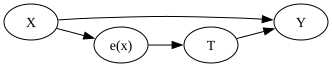

In [6]:
import graphviz as gr

g = gr.Digraph(graph_attr={"rankdir":"LR"})
g.edge("T", "Y")
g.edge("X", "Y")
g.edge("X", "e(x)")
g.edge("e(x)", "T")

g

- El **Propensity Score** es la probabilidad de recibir el tratamiento ($T=1$) dado un conjunto de covariables $X$:  
    $$
    e(x) = P(T=1 \mid X=x)
    $$

- **Intuición:** En vez de igualar a las personas en todas las variables, basta con igualarlas en su probabilidad de ser tratadas.

- **Reducción de dimensionalidad:** Resume toda la información de los confusores en un solo número entre 0 y 1.

- **Propiedad clave:** Si dos personas tienen el mismo $e(x)$, la asignación al tratamiento es "como si fuera aleatoria" entre ellas.

- **Independencia condicional:**  
    $$
    (Y_1, Y_0) \perp T \mid e(X)
    $$
    Es decir, dado el propensity score, el tratamiento es independiente de los potenciales resultados.



## Propensity Score Estimation

In [8]:
ps_model = smf.logit("""
    intervention ~ tenure + last_engagement_score + department_score
    + C(n_of_reports) + C(gender) + C(role)""", data=df.to_pandas()).fit(disp=0)

In [14]:
data_ps = df.with_columns(
    propensities=pl.Series(ps_model.predict(df.to_pandas())),
)

data_ps.select(["intervention", "engagement_score", "propensities"]).head(10)

intervention,engagement_score,propensities
i64,f64,f64
1,0.277359,0.596106
1,-0.449646,0.391138
1,0.769703,0.602578
1,-0.121763,0.58099
1,1.526147,0.619976
1,0.009607,0.57002
1,1.743033,0.653871
1,0.953294,0.695098
1,2.36778,0.60347


## Propensity Score an Orthogonalization

In [17]:
model = smf.ols("engagement_score ~ intervention + propensities",
    data=data_ps.to_pandas()).fit()
float(model.params["intervention"])

0.2633126749027772

- **¿Qué es el Propensity Score?**
  - Es la probabilidad condicional de recibir el tratamiento dado los confusores:  
    $$
    e(x) = P(T=1 \mid X=x)
    $$
- **¿Cómo se calcula?**
  - Usualmente mediante regresión logística:
    $$
    \log\left(\frac{e(x)}{1 - e(x)}\right) = \beta_0 + \beta_1 X_1 + \cdots + \beta_k X_k
    $$
- **Ventajas clave:**
  - **Reducción de dimensionalidad:** Resume todos los confusores $X$ en un solo número.
  - **Balanceo:** Si igualas en $e(x)$, igualas en la distribución de $X$ entre tratados y controles.
  - **Flexibilidad:** Permite usar técnicas de matching, weighting o estratificación para estimar el ATE.
  - **Captura relaciones no lineales:** Si usas modelos no lineales para estimar $e(x)$, puedes capturar relaciones complejas entre $X$ y $T$.

## Propensity Score Matching

In [22]:
from sklearn.neighbors import KNeighborsRegressor

T = "intervention"
X = "propensities"
Y = "engagement_score"

treated = data_ps.filter(pl.col(T) == 1)
control = data_ps.filter(pl.col(T) == 0)

mt0 = KNeighborsRegressor(n_neighbors=1).fit(
    control.select(X).to_numpy(),
    control.select(Y).to_numpy().ravel()
)
mt1 = KNeighborsRegressor(n_neighbors=1).fit(
    treated.select(X).to_numpy(),
    treated.select(Y).to_numpy().ravel()
)

predicted = pl.concat([
    treated.with_columns(
        match=pl.Series(mt0.predict(treated.select(X).to_numpy()))
    ),
    control.with_columns(
        match=pl.Series(mt1.predict(control.select(X).to_numpy()))
    )
])

predicted.head()

departament_id,intervention,engagement_score,tenure,n_of_reports,gender,role,last_engagement_score,department_score,department_size,propensities,match
i64,i64,f64,i64,i64,i64,i64,f64,f64,i64,f64,f64
76,1,0.277359,6,4,2,4,0.614261,0.224077,843,0.596106,0.55768
76,1,-0.449646,4,8,2,4,0.069636,0.224077,843,0.391138,-0.952622
76,1,0.769703,6,4,2,4,0.866918,0.224077,843,0.602578,-0.618381
76,1,-0.121763,6,4,2,4,0.029071,0.224077,843,0.58099,-1.404962
76,1,1.526147,6,4,1,4,0.589857,0.224077,843,0.619976,0.000354


In [36]:

ate = (
    (predicted.with_columns(
        ate=((pl.col(Y) - pl.col("match"))*(pl.col(T))
          + (pl.col("match") - pl.col(Y))*(1-pl.col(T))))
    ).select("ate").mean().item()
)
print("ATE:", ate)

ATE: 0.2877744347404597
